# Trực quan hóa kết quả mô hình

Notebook này cung cấp các ô để:

- Nạp checkpoint đã huấn luyện và đánh giá trên tập test.
- Vẽ ma trận nhầm lẫn (confusion matrix) và báo cáo phân loại (classification report).
- Nếu có lịch sử huấn luyện (log), vẽ đường loss/accuracy theo epoch.

Chạy từng ô theo thứ tự; cập nhật đường dẫn `ckpt_path` tới checkpoint bạn đã lưu.


Bảng so sánh kết quả cuối cùng:


,model,checkpoint,test_accuracy,test_f1_macro
0,prenorm,checkpoints\prenorm_1779095612.pt,0.900921,0.900558
1,postnorm,checkpoints\postnorm_1779096147.pt,0.871447,0.870641


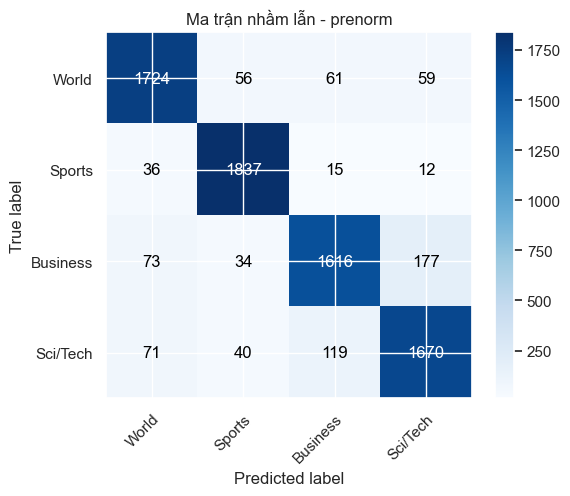

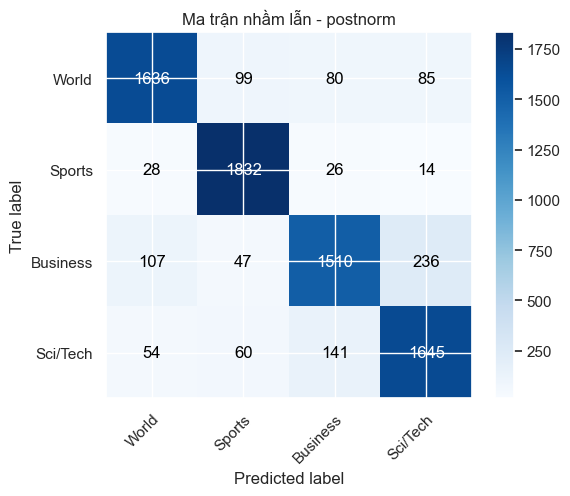

Đang vẽ history từ: d:\CS\Deep_Learning\-DL-Prenorm-Transformer-AGnews\notebooks\logs\history_postnorm_1779096147.csv


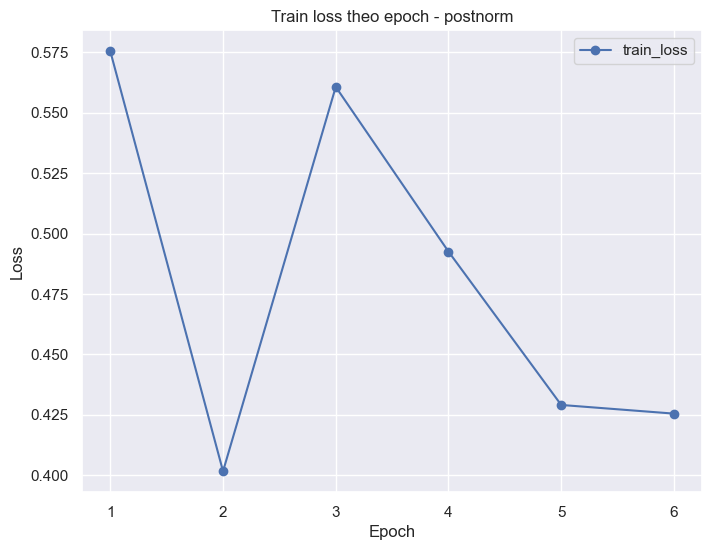

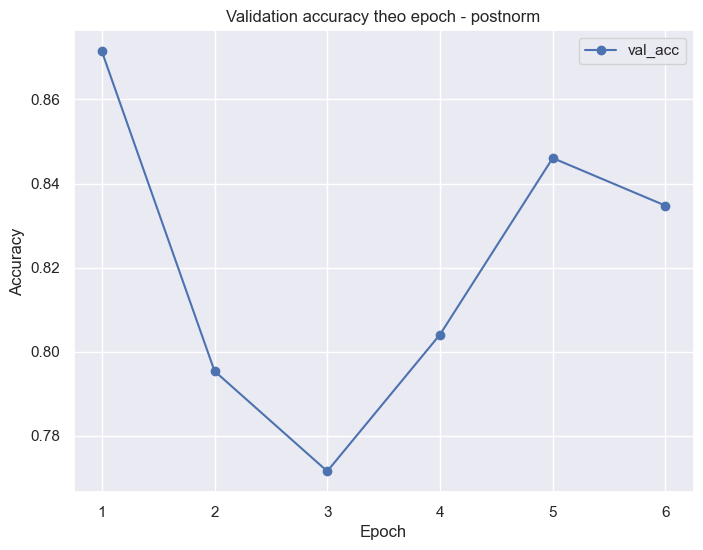

Đang vẽ history từ: d:\CS\Deep_Learning\-DL-Prenorm-Transformer-AGnews\notebooks\logs\history_prenorm_1779095612.csv


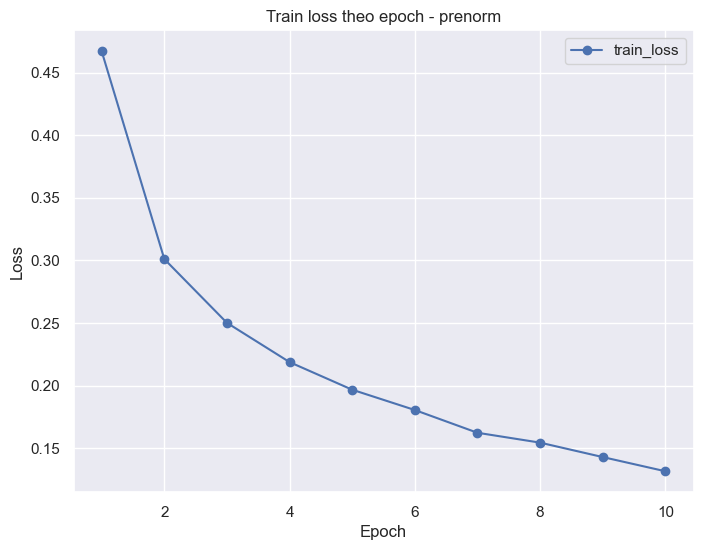

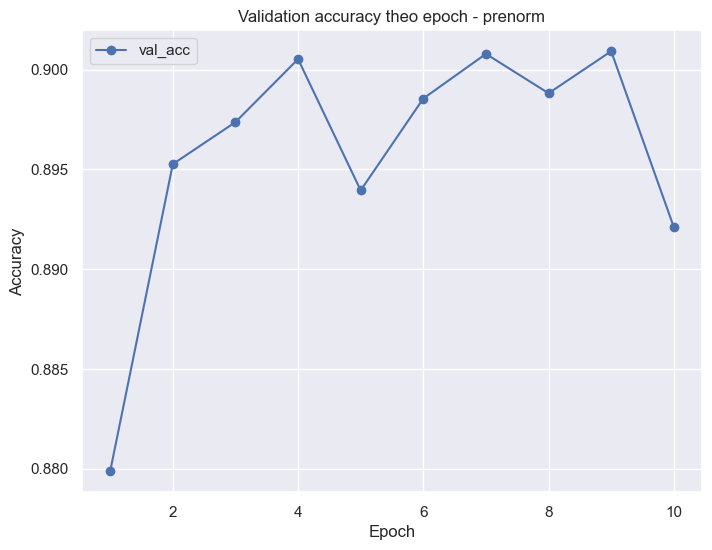

In [7]:
# Imports và trực quan từ kết quả đã lưu trong results/
import os
import sys
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set()
plt.rcParams['figure.figsize'] = (8, 6)

project_root = os.getcwd()
if not os.path.exists(os.path.join(project_root, 'train.py')):
    parent_root = os.path.abspath(os.path.join(project_root, '..'))
    if os.path.exists(os.path.join(parent_root, 'train.py')):
        project_root = parent_root
    else:
        repo_root = os.path.join(project_root, '-DL-Prenorm-Transformer-AGnews')
        if os.path.exists(os.path.join(repo_root, 'train.py')):
            project_root = repo_root
results_dir = os.path.join(project_root, 'results')
log_dirs = [
    os.path.join(project_root, 'logs'),
    os.path.join(project_root, 'notebooks', 'logs'),
    os.path.join(os.getcwd(), 'logs'),
]

# 1) Hiển thị bảng so sánh cuối cùng
comparison_path = os.path.join(results_dir, 'comparison_results.csv')
if os.path.exists(comparison_path):
    df = pd.read_csv(comparison_path)
    print('Bảng so sánh kết quả cuối cùng:')
    display(df)
else:
    print('Chưa có file comparison_results.csv. Hãy chạy notebook 03 trước.')

# 2) Vẽ confusion matrix của 2 mô hình
cm_path = os.path.join(results_dir, 'confusion_matrices.json')
labels = ['World', 'Sports', 'Business', 'Sci/Tech']

if os.path.exists(cm_path):
    with open(cm_path, 'r', encoding='utf-8') as f:
        cms = json.load(f)

    for model_name in ['prenorm', 'postnorm']:
        if model_name not in cms:
            continue
        cm = np.array(cms[model_name])
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.figure.colorbar(im, ax=ax)
        ax.set(
            xticks=np.arange(len(labels)),
            yticks=np.arange(len(labels)),
            xticklabels=labels,
            yticklabels=labels,
            ylabel='True label',
            xlabel='Predicted label',
            title=f'Ma trận nhầm lẫn - {model_name}'
        )
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

        thresh = cm.max() / 2.0 if cm.size > 0 else 0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color='white' if cm[i, j] > thresh else 'black')

        plt.tight_layout()
        plt.show()
else:
    print('Chưa có file confusion_matrices.json. Hãy chạy notebook 03 trước.')

# 3) Vẽ đường train_loss và val_acc từ log history_*.csv
history_files = []
for log_dir in log_dirs:
    history_files.extend(sorted(glob.glob(os.path.join(log_dir, 'history_*.csv'))))
history_files = sorted(set(history_files))
if history_files:
    for hp in history_files:
        hdf = pd.read_csv(hp)
        model_name = os.path.basename(hp).replace('history_', '').split('_')[0]
        print('Đang vẽ history từ:', hp)

        plt.figure()
        plt.plot(hdf['epoch'], hdf['train_loss'], marker='o', label='train_loss')
        plt.title(f'Train loss theo epoch - {model_name}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        if 'val_acc' in hdf.columns:
            plt.figure()
            plt.plot(hdf['epoch'], hdf['val_acc'], marker='o', label='val_acc')
            plt.title(f'Validation accuracy theo epoch - {model_name}')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.show()
else:
    print('Không tìm thấy history_*.csv trong bất kỳ thư mục logs nào.')